**2nd Assignment - Pengenalan Pola KOM** <br>
**Farsya Nabila Tori [24/543855/PA/23113]**

Implementasikan histogram of energy, histogram of zero crossing rate, histogram of energy entropy tanpa menggunakan library.

##**Time Domain Features**

Time domain features adalah representasi abstrak dari sinyal audio yang memroses sinyal secara langsung dan bersifat (1) distinctive, yakni dapat membedakan pola sinyal yang berbeda, dan (2) compact, yakni memiliki makna atau berguna untuk analisis. Berbeda dengan frequency domain yang mengonversi ke domain frekuensi terlebih dahulu, seperti MFCC dan Mel filterbank, contoh time domain adalah audio energy, zero crossing rate (ZCR), dan energi entropi. <br> <br> Penjelasannya adalah sebagai berikut. <br>
**(1) Audio Energy:** menghitung jumlah kuadrat amplitudo tiap sampel dalam window. Apabila audio silence, energi rendah. Sementara speech, punya variansi energi yang lebih tinggi dari musik. <br>
**(2) Zero Crossing Rate (ZCR):** menghitung berapa kali sinyal berubah dari positif ke negatif (atau sebaliknya). ZCR berguna untuk mendeteksi voiced/unvoiced speech. <br>
**(3) Entropy of Energy:** menangkap perubahan drastis/smooth dari data audio. Entropi rendah berarti perubahan drastis, seperti adanya tembakan atau ledakan. Hal ini berguna untuk mendeteksi event audio. <br>
<br> Pada tugas kali ini, digunakan dataset audio dari ESC-50 dengan memilih 3 kategori dari 50 kelas, yakni
*   Music: piano, guitar, violin_fiddle, flute → sinyal periodik, energi stabil
*   Speech: clapping, sneezing, laughing, crying_baby → variasi energi, ZCR sedang
*   Noise: rain, sea_waves, wind, crackling_fire → acak, entropi tinggi










###**Load & Preprocessing Audio**

In [1]:
!git clone https://github.com/karolpiczak/ESC-50.git

Cloning into 'ESC-50'...
remote: Enumerating objects: 4199, done.
remote: Counting objects: 100% (69/69), done.
remote: Compressing objects: 100% (35/35), done.
remote: Total 4199 (delta 62), reused 34 (delta 34), pack-reused 4130 (from 1)
Receiving objects: 100% (4199/4199), 878.77 MiB | 25.75 MiB/s, done.
Resolving deltas: 100% (292/292), done.
Updating files: 100% (2011/2011), done.


In [2]:
import wave
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

BASE_PATH = "/content/ESC-50"
META_PATH = os.path.join(BASE_PATH, "meta/esc50.csv")
AUDIO_PATH = os.path.join(BASE_PATH, "audio")

# (1) Load metadata
meta = pd.read_csv(META_PATH)
print("Kolom yang tersedia:", meta.columns.tolist())
print(f"Total file: {len(meta)}")
print(meta.head())

Kolom yang tersedia: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take']
Total file: 2000
            filename  fold  target        category  esc10  src_file take
0   1-100032-A-0.wav     1       0             dog   True    100032    A
1  1-100038-A-14.wav     1      14  chirping_birds  False    100038    A
2  1-100210-A-36.wav     1      36  vacuum_cleaner  False    100210    A
3  1-100210-B-36.wav     1      36  vacuum_cleaner  False    100210    B
4  1-101296-A-19.wav     1      19    thunderstorm  False    101296    A


In [3]:
# (2) Definisi Kelas
CATEGORY_MAP = {
    "music": ["church_bells", "clock_tick", "crickets", "insects"],
    "speech": ["laughing", "crying_baby", "clapping", "sneezing"],
    "noise": ["rain", "sea_waves", "wind", "crackling_fire"]
}

all_selected = []
for category, classes in CATEGORY_MAP.items():
    subset = meta[meta["category"].isin(classes)].copy()
    subset["group"] = category
    all_selected.append(subset)

df = pd.concat(all_selected).reset_index(drop=True)

print(f"Total file yang digunakan: {len(df)}")
print(df.groupby("group")["category"].value_counts())

Total file yang digunakan: 480
group   category      
music   church_bells      40
        clock_tick        40
        crickets          40
        insects           40
noise   crackling_fire    40
        rain              40
        sea_waves         40
        wind              40
speech  clapping          40
        crying_baby       40
        laughing          40
        sneezing          40
Name: count, dtype: int64


In [4]:
# (3) Load File
def load_wav(filepath):
    with wave.open(filepath, 'rb') as wf:
        n_channels   = wf.getnchannels()
        sampwidth     = wf.getsampwidth()
        sample_rate   = wf.getframerate()
        n_frames      = wf.getnframes()

        raw_data = wf.readframes(n_frames)

    fmt_map = {1: 'b', 2: 'h', 4: 'i'}
    fmt = f"{n_frames * n_channels}{fmt_map[sampwidth]}"
    signal = np.array(struct.unpack(fmt, raw_data), dtype=np.float64)

    if n_channels == 2:
        signal = signal.reshape(-1, 2).mean(axis=1)

    max_val = float(2 ** (8 * sampwidth - 1))
    signal = signal / max_val

    return signal, sample_rate

sample_row = df.iloc[0]
sample_path = os.path.join(AUDIO_PATH, sample_row["filename"])

signal, sr = load_wav(sample_path)

print(f"File     : {sample_row['filename']}")
print(f"Kategori : {sample_row['group']} → {sample_row['category']}")
print(f"Sample rate : {sr} Hz")
print(f"Durasi      : {len(signal)/sr:.2f} detik")
print(f"Jumlah sampel: {len(signal)}")
print(f"Min/Max signal: {signal.min():.4f} / {signal.max():.4f}")

File     : 1-13571-A-46.wav
Kategori : music → church_bells
Sample rate : 44100 Hz
Durasi      : 5.00 detik
Jumlah sampel: 220500
Min/Max signal: -1.0000 / 1.0000


In [5]:
# (4) Load dan Simpan ke Dictionary
def load_all_audio(df, audio_path):
    data = {"music": [], "speech": [], "noise": []}
    failed = []

    for _, row in df.iterrows():
        filepath = os.path.join(audio_path, row["filename"])
        try:
            signal, sr = load_wav(filepath)
            data[row["group"]].append({
                "signal"   : signal,
                "sr"       : sr,
                "filename" : row["filename"],
                "category" : row["category"]
            })
        except Exception as e:
            failed.append((row["filename"], str(e)))

    for group, items in data.items():
        print(f" {group:8s}: {len(items)} file loaded")
    if failed:
        print(f"\nGagal load {len(failed)} file: {failed}")

    return data

audio_data = load_all_audio(df, AUDIO_PATH)

 music   : 160 file loaded
 speech  : 160 file loaded
 noise   : 160 file loaded


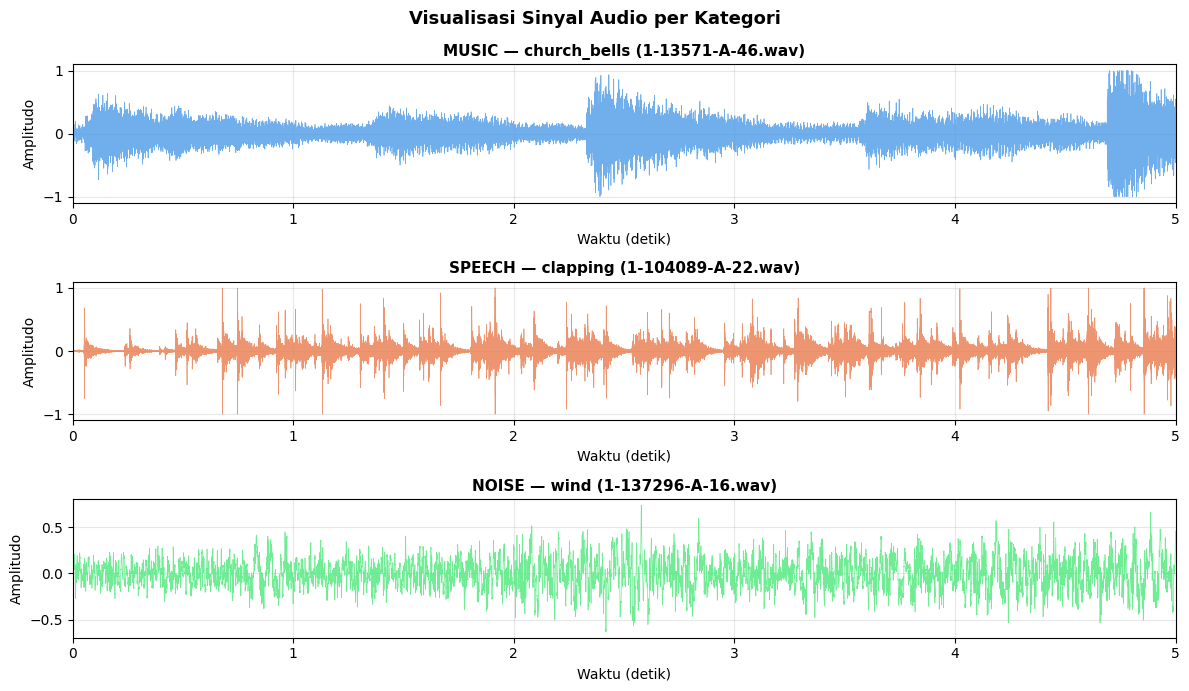

In [6]:
# (5) Visualisasi Sinyal
fig, axes = plt.subplots(3, 1, figsize=(12, 7))
groups = ["music", "speech", "noise"]
colors = ["#4C9BE8", "#E87B4C", "#4CE87B"]

for ax, group, color in zip(axes, groups, colors):
    if len(audio_data[group]) == 0:
        ax.set_title(f"{group.upper()} — ⚠️ Tidak ada file!", color="red")
        continue

    sample = audio_data[group][0]
    signal = sample["signal"]
    sr     = sample["sr"]
    t      = np.linspace(0, len(signal)/sr, len(signal))

    ax.plot(t, signal, color=color, linewidth=0.5, alpha=0.8)
    ax.set_title(f"{group.upper()} — {sample['category']} ({sample['filename']})",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel("Waktu (detik)")
    ax.set_ylabel("Amplitudo")
    ax.set_xlim([0, t[-1]])
    ax.grid(True, alpha=0.3)

plt.suptitle("Visualisasi Sinyal Audio per Kategori", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Analisis Hasil** <br>
Dapat diperhatikan bahwa berdasarkan visualisasi sinyal audio tersebut, karakteristik gelombang audio ini berbeda-beda untuk setiap kategori. Kategori music yang diwakili oleh suara church_bells ini menunjukkan amplitudo yang cenderung tidak merata, yakniada silence, ada lonjakan tinggi. <br> <br>
Sementara kategori speech yang diwakili oleh suara clapping lebih rapat dan konsisten sepanjang 5 detik meski dalam bentuk yang pendek dan padat (ZCR tinggi). Terakhir, kategori noise yang diwakili oleh suara wind, amplitudonya relatif rendah dan tanpa pola yang jelas apabila dibandingkan dengan music dan speech.

###**Histogram of Energy**

In [7]:
# (1) Framing Sinyal
def framing(signal, sr, frame_duration=0.025, hop_duration=0.010):
    frame_length = int(sr * frame_duration)
    hop_length   = int(sr * hop_duration)

    n_frames = 1 + (len(signal) - frame_length) // hop_length

    frames = np.array([
        signal[i * hop_length : i * hop_length + frame_length]
        for i in range(n_frames)
    ])

    return frames

test_signal = audio_data["music"][0]["signal"]
test_sr     = audio_data["music"][0]["sr"]
frames      = framing(test_signal, test_sr)

print(f"Panjang sinyal   : {len(test_signal)} sampel")
print(f"Jumlah frame     : {frames.shape[0]}")
print(f"Panjang per frame: {frames.shape[1]} sampel (~25ms)")

Panjang sinyal   : 220500 sampel
Jumlah frame     : 498
Panjang per frame: 1102 sampel (~25ms)


In [8]:
# (2) Energi per Frame
def compute_energy(frames):
    energies = np.array([
        np.sum(frame ** 2)
        for frame in frames
    ])
    return energies

test_frames   = framing(test_signal, test_sr)
test_energies = compute_energy(test_frames)

print(f"Jumlah nilai energi: {len(test_energies)}")
print(f"Energy min : {test_energies.min():.6f}")
print(f"Energy max : {test_energies.max():.6f}")
print(f"Energy mean: {test_energies.mean():.6f}")

Jumlah nilai energi: 498
Energy min : 2.939170
Energy max : 287.387522
Energy mean: 29.302559


In [9]:
# (3) Energi untuk Semua File per Kategori
def extract_energy_all(audio_data):
    energy_dict = {}

    for group, files in audio_data.items():
        all_energies = []
        for item in files:
            frames   = framing(item["signal"], item["sr"])
            energies = compute_energy(frames)
            all_energies.extend(energies.tolist())

        energy_dict[group] = np.array(all_energies)
        print(f" {group:8s}: {len(all_energies):>8,} nilai energi")

    return energy_dict

energy_dict = extract_energy_all(audio_data)

 music   :   79,680 nilai energi
 speech  :   79,680 nilai energi
 noise   :   79,680 nilai energi


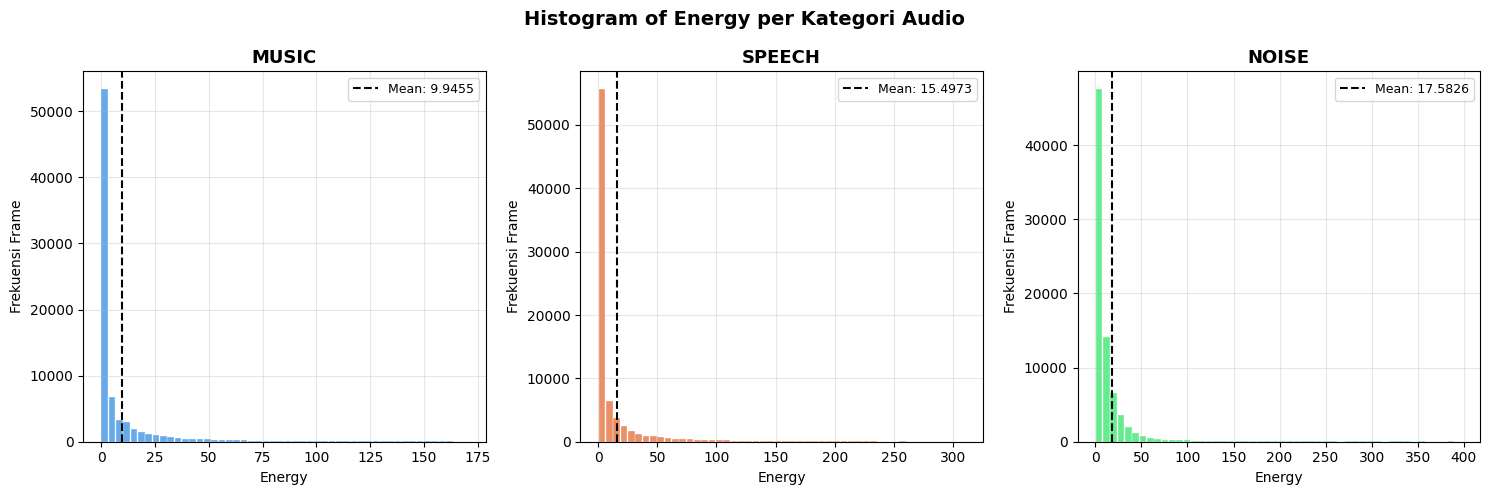


 Statistik Energi:
Kategori         Mean        Std     Median        Max
music         9.94547   26.81407    0.77191  517.15554
speech       15.49726   45.17612    0.55854  784.83461
noise        17.58261   50.42194    5.67347 1012.25617


In [10]:
# (4) Plot Histogram of Energy
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups = ["music", "speech", "noise"]
colors = ["#4C9BE8", "#E87B4C", "#4CE87B"]
n_bins = 50

for ax, group, color in zip(axes, groups, colors):
    energies = energy_dict[group]

    threshold = np.percentile(energies, 99.5)
    energies_clipped = energies[energies <= threshold]

    counts, bin_edges = np.histogram(energies_clipped, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    ax.bar(bin_centers, counts, width=bin_width * 0.9,
           color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

    ax.set_title(f"{group.upper()}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Energy")
    ax.set_ylabel("Frekuensi Frame")
    ax.grid(True, alpha=0.3)

    ax.axvline(np.mean(energies), color='black', linestyle='--',
               linewidth=1.5, label=f"Mean: {np.mean(energies):.4f}")
    ax.legend(fontsize=9)

plt.suptitle("Histogram of Energy per Kategori Audio", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("histogram_energy.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Statistik Energi:")
print(f"{'Kategori':<10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Max':>10}")
for group in groups:
    e = energy_dict[group]
    print(f"{group:<10} {np.mean(e):>10.5f} {np.std(e):>10.5f} "
          f"{np.median(e):>10.5f} {np.max(e):>10.5f}")

**Analisis Hasil** <br>
Ketiga kategori audio menunjukkan distribusi
yang right-skewed (condong ke kanan), artinya sebagian besar frame memiliki energi rendah
dengan sedikit frame yang memiliki energi sangat tinggi. <br>
*   Kategori music memiliki mean energi paling rendah (9.94) yang berarti adanya banyak frame silent di antara dentingan
lonceng, sesuai dengan pola waveform yang terputus-putus.

*   Kategori speech
memiliki mean energi sedang (15.49) dan median yang sangat kecil (0.55), menandakan
distribusi energi yang tidak merata antara frame aktif dan frame jeda antartepukan.


*   Sementara itu, kategori noise justru memiliki mean tertinggi (17.58)
sekaligus median tertinggi (5.67), yang berarti energi tersebar lebih merata di tiap frame tanpa jeda signifikan yang konsisten dengan sifat stokastiknya yang terus-menerus.






###**Histogram of Zero Crossing Rate (ZCR)**

In [11]:
# (1) ZCR per Frame
def compute_zcr(frames):
    zcr = np.array([
        np.sum(frame[:-1] * frame[1:] < 0) / (len(frame) - 1)
        for frame in frames
    ])
    return zcr

test_frames = framing(test_signal, test_sr)
test_zcr    = compute_zcr(test_frames)

print(f"Jumlah nilai ZCR : {len(test_zcr)}")
print(f"ZCR min  : {test_zcr.min():.6f}")
print(f"ZCR max  : {test_zcr.max():.6f}")
print(f"ZCR mean : {test_zcr.mean():.6f}")

Jumlah nilai ZCR : 498
ZCR min  : 0.012716
ZCR max  : 0.075386
ZCR mean : 0.033526


In [12]:
# (2) ZCR untuk Semua File per Kategori
def extract_zcr_all(audio_data):
    zcr_dict = {}

    for group, files in audio_data.items():
        all_zcr = []
        for item in files:
            frames = framing(item["signal"], item["sr"])
            zcr    = compute_zcr(frames)
            all_zcr.extend(zcr.tolist())

        zcr_dict[group] = np.array(all_zcr)
        print(f"{group:8s}: {len(all_zcr):>8,} nilai ZCR")

    return zcr_dict

zcr_dict = extract_zcr_all(audio_data)

music   :   79,680 nilai ZCR
speech  :   79,680 nilai ZCR
noise   :   79,680 nilai ZCR


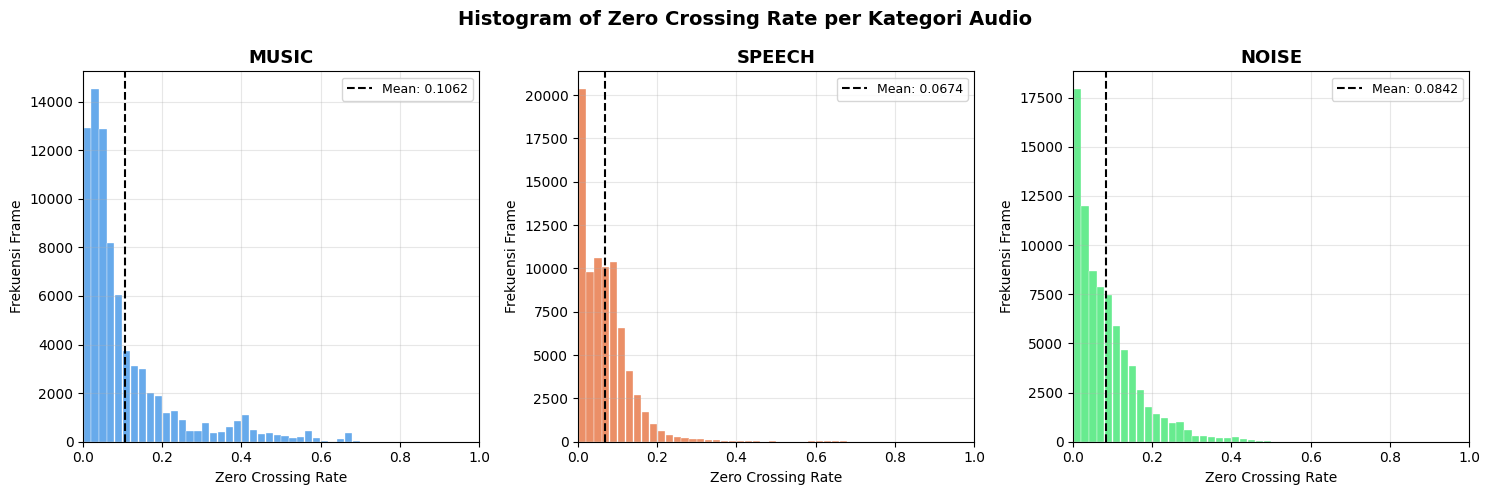


 Statistik ZCR:
Kategori         Mean        Std     Median        Max
music         0.10616    0.12433    0.05995    0.69482
speech        0.06741    0.06476    0.05813    0.71026
noise         0.08420    0.07936    0.06358    0.53769


In [13]:
# (3) Plot Histogram of ZCR
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups = ["music", "speech", "noise"]
colors = ["#4C9BE8", "#E87B4C", "#4CE87B"]
n_bins = 50

for ax, group, color in zip(axes, groups, colors):
    zcr_values = zcr_dict[group]

    counts, bin_edges = np.histogram(zcr_values, bins=n_bins, range=(0, 1))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    ax.bar(bin_centers, counts, width=bin_width * 0.9,
           color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

    ax.axvline(np.mean(zcr_values), color='black', linestyle='--',
               linewidth=1.5, label=f"Mean: {np.mean(zcr_values):.4f}")

    ax.set_title(f"{group.upper()}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Zero Crossing Rate")
    ax.set_ylabel("Frekuensi Frame")
    ax.set_xlim([0, 1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Histogram of Zero Crossing Rate per Kategori Audio",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("histogram_zcr.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n Statistik ZCR:")
print(f"{'Kategori':<10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Max':>10}")
for group in groups:
    z = zcr_dict[group]
    print(f"{group:<10} {np.mean(z):>10.5f} {np.std(z):>10.5f} "
          f"{np.median(z):>10.5f} {np.max(z):>10.5f}")

**Analisis Hasil** <br>
*   Kategori music memiliki mean ZCR tertinggi (0.106) dengan distribusi paling
tersebar hingga nilai 0.7.
*   Mean ZCR terendah ada pada kategori speech, yakni 0.067 dengan distribusi paling sempit dan terpusat di sekitar nilai kecil. Artinya, karakteristik speech, seperti clapping dan crying_baby dalam satu frame yang didominasi silence antarburst, pergantian tanda sinyal relatif jarang terjadi.
*   Kategori noise berada di tengah dengan mean ZCR 0.084 dan distribusi yang cukup
tersebar, tetapi tidak setinggi osilasi pada kategori music.

###**Histogram of Energy Entropy**

In [19]:
# (1) Energy Entropy per Frame
def compute_energy_entropy(frames, n_subframes=10):
    entropies = []

    for frame in frames:
        frame_len    = len(frame)
        sub_len      = frame_len // n_subframes

        sub_energies = np.array([
            np.sum(frame[k * sub_len : (k+1) * sub_len] ** 2)
            for k in range(n_subframes)
        ])

        total_energy = np.sum(sub_energies)
        if total_energy < 1e-10:
            entropies.append(0.0)
            continue

        p = sub_energies / total_energy
        p = np.where(p > 0, p, 1e-10)

        H = -np.sum(p * np.log2(p))
        entropies.append(H)

    return np.array(entropies)

test_frames  = framing(test_signal, test_sr)
test_entropy = compute_energy_entropy(test_frames)

print(f"Jumlah nilai Entropy : {len(test_entropy)}")
print(f"Entropy min  : {test_entropy.min():.6f}")
print(f"Entropy max  : {test_entropy.max():.6f}")
print(f"Entropy mean : {test_entropy.mean():.6f}")
print(f"Entropy max teoritis (log2(10)) : {np.log2(10):.6f}")

Jumlah nilai Entropy : 498
Entropy min  : 1.853677
Entropy max  : 3.301035
Entropy mean : 3.179342
Entropy max teoritis (log2(10)) : 3.321928


In [20]:
# (2) Energy Entropy untuk Semua File per Frame
def extract_entropy_all(audio_data, n_subframes=10):
    entropy_dict = {}

    for group, files in audio_data.items():
        all_entropy = []
        for item in files:
            frames  = framing(item["signal"], item["sr"])
            entropy = compute_energy_entropy(frames, n_subframes)
            all_entropy.extend(entropy.tolist())

        entropy_dict[group] = np.array(all_entropy)
        print(f"{group:8s}: {len(all_entropy):>8,} nilai entropy")

    return entropy_dict

entropy_dict = extract_entropy_all(audio_data)

music   :   79,680 nilai entropy
speech  :   79,680 nilai entropy
noise   :   79,680 nilai entropy


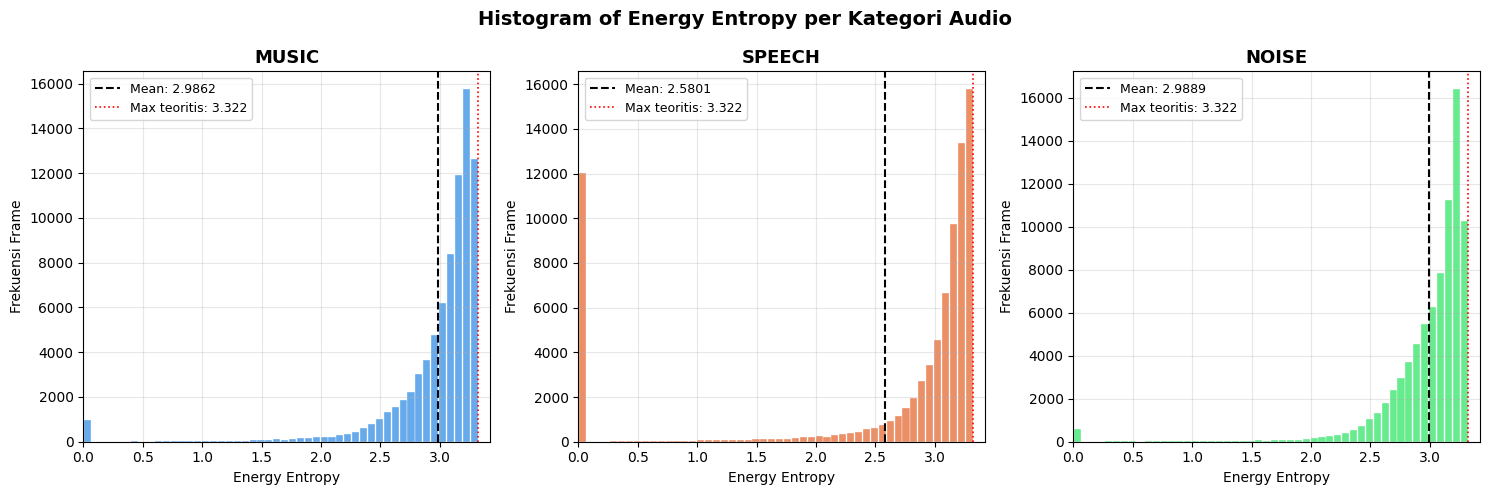


Statistik Energy Entropy:
Kategori         Mean        Std     Median        Max
music         2.98621    0.45781    3.12576    3.32147
speech        2.58006    1.13911    3.11502    3.32193
noise         2.98894    0.40464    3.10789    3.32193


In [21]:
# (3) Plot Histogram Energy of Entropy
MAX_ENTROPY = np.log2(10)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

groups = ["music", "speech", "noise"]
colors = ["#4C9BE8", "#E87B4C", "#4CE87B"]
n_bins = 50

for ax, group, color in zip(axes, groups, colors):
    entropy_vals = entropy_dict[group]

    counts, bin_edges = np.histogram(entropy_vals, bins=n_bins,
                                     range=(0, MAX_ENTROPY))
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    bin_width   = bin_edges[1] - bin_edges[0]

    ax.bar(bin_centers, counts, width=bin_width * 0.9,
           color=color, alpha=0.85, edgecolor='white', linewidth=0.3)

    ax.axvline(np.mean(entropy_vals), color='black', linestyle='--',
               linewidth=1.5, label=f"Mean: {np.mean(entropy_vals):.4f}")

    ax.axvline(MAX_ENTROPY, color='red', linestyle=':',
               linewidth=1.2, label=f"Max teoritis: {MAX_ENTROPY:.3f}")

    ax.set_title(f"{group.upper()}", fontsize=13, fontweight='bold')
    ax.set_xlabel("Energy Entropy")
    ax.set_ylabel("Frekuensi Frame")
    ax.set_xlim([0, MAX_ENTROPY + 0.1])
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("Histogram of Energy Entropy per Kategori Audio",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("histogram_entropy.png", dpi=150, bbox_inches='tight')
plt.show()

# Ringkasan statistik
print("\nStatistik Energy Entropy:")
print(f"{'Kategori':<10} {'Mean':>10} {'Std':>10} {'Median':>10} {'Max':>10}")
for group in groups:
    e = entropy_dict[group]
    print(f"{group:<10} {np.mean(e):>10.5f} {np.std(e):>10.5f} "
          f"{np.median(e):>10.5f} {np.max(e):>10.5f}")

**Analisis Hasil** <br>
Histogram Energy Entropy menghasilkan pola yang cukup informatif, seperti:

*   Kategori music memiliki mean entropy tinggi (2.986) dengan distribusi yang left-skewed, artinya sebagian besar frame aktif memiliki energi yang terdistribusi merata antarsubframe, sementara sedikit frame silence menarik distribusi ke kiri.
*   Sementara itu, kategori speech menunjukkan bimodal dengan std terbesar (1.139). Puncak pertama di sekitar nilai 0 merepresentasikan frame senyap antarburst dan puncak kedua mendekati nilai maksimum merepresentasikan frame aktif. Mean-nya (2.580)
paling rendah karena proporsi frame senyap yang besar menarik rata-rata ke bawah.

*   Kategori noise memiliki mean entropy tertinggi (2.989) sekaligus std terkecil (0.405) yang menunjukkan energi tersebar sangat merata di tiap sub-frame secara konsisten tanpa jeda sehingga entropinya selalu tinggi.

####**Kesimpulan**
Hasilnya menunjukkan bahwa ketiga fitur bersifat komplementer. <br>
(1) Energy efektif membedakan noise dari music, tetapi overlap antara speech dan noise membuatnya kurang optimal sebagai
diskriminator tunggal. <br>
(2) ZCR menunjukkan nilai yang sangat bergantung pada komposisi kategori sehingga kurang robust apabila berdiri sendiri. <br>
(3) Energy entropy terbukti sangat informatif, terutama dalam mengidentifikasi speech melalui distribusi bimodal dengan standar deviasi yang jauh lebih besar dibandingkan kategori lainnya. <br>
Secara keseluruhan,
kombinasi ketiga fitur ini akan lebih optimal sebagai feature vector dalam sistem klasifikasi
pola audio dibandingkan menggunakan satu fitur saja.

####**Referensi**
*   Giannakopoulos, T., & Pikrakis, A. (2014). *Introduction to Audio Analysis: A MATLAB Approach*. Academic Press, Elsevier.
*   Wahyono. (n.d.). Feature Extraction on Audio Data [Slide kuliah]. Departemen Ilmu Komputer dan Elektronika, FMIPA, Universitas Gadjah Mada.



##